# Model Selection & Evaluation — Final Clean Version

This notebook evaluates the final models for the Pokémon Meta-Balance Decision Support Tool.

## Final evaluation framing

- **Balance Risk** is evaluated as an **unsupervised anomaly-detection** task.
  - No accuracy, F1-score, classification report, or confusion matrix is used.
  - Evaluation focuses on anomaly counts, category distribution, interpretability, and optional PCA visual validation.

- **Competitive Longevity** is evaluated as a **regression** task.
  - Evaluation uses RMSE, MAE, R², true-vs-predicted behaviour, and feature importance.
  - The target is the final 1–5 longevity score derived from Base Stat Total, not the raw Roman-numeral generation column.

This version removes the earlier classification-style longevity evaluation that produced misleading accuracy/F1 outputs.


In [33]:
# ---------------------------------------------------------
# 0. Imports and display settings
# ---------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)


In [34]:
# ---------------------------------------------------------
# 1. Locate project paths robustly
# ---------------------------------------------------------
# This allows the notebook to run from /notebooks, project root, or another nearby folder.

def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    candidates = [start] + list(start.parents)
    # Also try common notebook locations when executed from exported/temporary folders.
    candidates += [Path(".."), Path("../.."), Path("/mnt/data")]

    for p in candidates:
        p = p.resolve()
        if (p / "data" / "final_processed_dataset.csv").exists():
            return p
        if (p / "final_processed_dataset.csv").exists():
            return p
    raise FileNotFoundError(
        "Could not find final_processed_dataset.csv. "
        "Place this notebook in the project notebooks/ folder or update PROJECT_ROOT manually."
    )

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" if (PROJECT_ROOT / "data").exists() else PROJECT_ROOT
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Models directory:", MODELS_DIR)


Project root: D:\ml_assignment\Predictive-Meta-Balance-System-for-Pokemon\poke-balance-sentinel
Data directory: D:\ml_assignment\Predictive-Meta-Balance-System-for-Pokemon\poke-balance-sentinel\data
Models directory: D:\ml_assignment\Predictive-Meta-Balance-System-for-Pokemon\poke-balance-sentinel\models


In [35]:
# ---------------------------------------------------------
# 2. Load data
# ---------------------------------------------------------
processed_path = DATA_DIR / "final_processed_dataset.csv"
raw_path = DATA_DIR / "pokemon_complete_2025.csv"

df = pd.read_csv(processed_path)
print("Processed dataset shape:", df.shape)
print("Processed dataset columns:")
print(df.columns.tolist())

if raw_path.exists():
    df_raw = pd.read_csv(raw_path)
    print("\nRaw dataset shape:", df_raw.shape)
else:
    df_raw = None
    print("\nRaw dataset not found. This is okay because final evaluation uses final_processed_dataset.csv.")


Processed dataset shape: (1025, 40)
Processed dataset columns:
['pokedex_id', 'num_types', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_stat_total', 'height_m', 'weight_kg', 'base_experience', 'capture_rate', 'base_happiness', 'hatch_counter', 'gender_rate', 'bmi', 'attack_defense_ratio', 'physical_total', 'special_total', 'offensive_total', 'defensive_total', 'type_bug', 'type_dark', 'type_dragon', 'type_electric', 'type_fairy', 'type_fighting', 'type_fire', 'type_flying', 'type_ghost', 'type_grass', 'type_ground', 'type_ice', 'type_normal', 'type_poison', 'type_psychic', 'type_rock', 'type_steel', 'type_water']

Raw dataset shape: (1025, 43)


In [36]:
# ---------------------------------------------------------
# 3. Final feature schemas used by the project/app
# ---------------------------------------------------------
BASE_STAT_FEATURES = ["hp", "attack", "defense", "sp_attack", "sp_defense", "speed"]
TYPE_FEATURES = sorted([c for c in df.columns if c.startswith("type_")])
LONGEVITY_FEATURES = BASE_STAT_FEATURES + TYPE_FEATURES

missing_base = [c for c in BASE_STAT_FEATURES if c not in df.columns]
if missing_base:
    raise ValueError(f"Missing required base stat columns: {missing_base}")

print("Balance Risk final features:", BASE_STAT_FEATURES)
print("Longevity final feature count:", len(LONGEVITY_FEATURES))
print("Longevity type features:", TYPE_FEATURES)


Balance Risk final features: ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
Longevity final feature count: 24
Longevity type features: ['type_bug', 'type_dark', 'type_dragon', 'type_electric', 'type_fairy', 'type_fighting', 'type_fire', 'type_flying', 'type_ghost', 'type_grass', 'type_ground', 'type_ice', 'type_normal', 'type_poison', 'type_psychic', 'type_rock', 'type_steel', 'type_water']


## Balance Risk Evaluation — Unsupervised Setup

The balance-risk model is evaluated as an anomaly detector. It uses only the six core base stats. This avoids using hand-written “broken/balanced” labels as the evaluation target.


In [37]:
# ---------------------------------------------------------
# 4. Load or recreate the final 6-stat Balance Risk model
# ---------------------------------------------------------
# Preferred final artifact from the final unsupervised notebook:
#   models/unsupervised_balance_risk_6stats.joblib
# Deployment may also use:
#   models/unsupervised_balance_risk_pipeline.joblib
# If a loaded artifact expects an older broad schema, this cell recreates the clean final 6-stat pipeline.

balance_model_candidates = [
    MODELS_DIR / "unsupervised_balance_risk_6stats.joblib",
    MODELS_DIR / "unsupervised_balance_risk_pipeline.joblib",
]

X_balance = df[BASE_STAT_FEATURES].copy().apply(pd.to_numeric, errors="coerce").fillna(0)

def model_expected_features(model):
    if hasattr(model, "feature_names_in_"):
        return list(model.feature_names_in_)
    if hasattr(model, "steps"):
        for _, step in model.steps:
            if hasattr(step, "feature_names_in_"):
                return list(step.feature_names_in_)
    return None

balance_model = None
loaded_balance_path = None
for path in balance_model_candidates:
    if path.exists():
        candidate = joblib.load(path)
        expected = model_expected_features(candidate)
        # Accept models with no recorded feature names or exactly the six-stat schema.
        if expected is None or set(expected) == set(BASE_STAT_FEATURES):
            balance_model = candidate
            loaded_balance_path = path
            break
        else:
            print(f"Skipping {path.name}: saved artifact expects {len(expected)} features, not the final 6-stat schema.")
            print("Expected by artifact:", expected)

if balance_model is None:
    print("No valid final 6-stat balance artifact found. Recreating the final unsupervised Isolation Forest pipeline...")
    balance_model = Pipeline([
        ("scaler", StandardScaler()),
        ("anomaly_detector", IsolationForest(
            random_state=42,
            contamination=0.07,
            n_estimators=100,
            n_jobs=1
        ))
    ])
    balance_model.fit(X_balance)
    loaded_balance_path = MODELS_DIR / "unsupervised_balance_risk_6stats.joblib"
    joblib.dump(balance_model, loaded_balance_path)
    print("Saved recreated final 6-stat model to:", loaded_balance_path)
else:
    print("Loaded balance-risk model from:", loaded_balance_path)

print("Balance model type:", type(balance_model))
print("Balance model expected features:", model_expected_features(balance_model))


Loaded balance-risk model from: D:\ml_assignment\Predictive-Meta-Balance-System-for-Pokemon\poke-balance-sentinel\models\unsupervised_balance_risk_6stats.joblib
Balance model type: <class 'sklearn.pipeline.Pipeline'>
Balance model expected features: ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']


In [38]:
# ---------------------------------------------------------
# 5. Balance Risk predictions and category interpretation
# ---------------------------------------------------------
# IsolationForest returns:
#   1  = normal
#  -1  = anomaly
# Anomalies are interpreted as Overpowered or Underpowered using six-stat BST relative to the dataset median.

balance_labels = balance_model.predict(X_balance)

if hasattr(balance_model, "decision_function"):
    balance_scores = balance_model.decision_function(X_balance)
else:
    balance_scores = np.full(len(X_balance), np.nan)

eval_balance = df.copy()
eval_balance["anomaly_label"] = balance_labels
eval_balance["raw_risk_score"] = balance_scores
eval_balance["base_stat_total_6"] = X_balance.sum(axis=1)
median_bst_6 = eval_balance["base_stat_total_6"].median()

def categorize_balance(row):
    if row["anomaly_label"] == 1:
        return "Normal"
    if row["base_stat_total_6"] >= median_bst_6:
        return "Overpowered"
    return "Underpowered"

eval_balance["balance_category"] = eval_balance.apply(categorize_balance, axis=1)

balance_label_counts = (
    pd.Series(balance_labels)
    .map({1: "Normal", -1: "Anomaly"})
    .value_counts()
    .rename_axis("IsolationForest Output")
    .reset_index(name="Count")
)

balance_category_counts = (
    eval_balance["balance_category"]
    .value_counts()
    .reindex(["Normal", "Overpowered", "Underpowered"])
    .fillna(0)
    .astype(int)
    .rename_axis("Balance Category")
    .reset_index(name="Count")
)

print("Median six-stat BST used for anomaly interpretation:", median_bst_6)
print("\nIsolationForest output counts:")
display(balance_label_counts)
print("\nFinal balance category counts:")
display(balance_category_counts)

# Optional diagnostic only: silhouette on the final 6-stat feature space.
# This is not a supervised accuracy score.
if len(np.unique(balance_labels)) > 1:
    X_balance_scaled = StandardScaler().fit_transform(X_balance)
    sil_score = silhouette_score(X_balance_scaled, balance_labels)
else:
    sil_score = np.nan

balance_eval_summary = pd.DataFrame([
    {"Metric": "Total Samples", "Value": len(eval_balance)},
    {"Metric": "Normal Count", "Value": int((balance_labels == 1).sum())},
    {"Metric": "Anomaly Count", "Value": int((balance_labels == -1).sum())},
    {"Metric": "6-stat Silhouette Score", "Value": round(float(sil_score), 4) if not np.isnan(sil_score) else np.nan},
])
print("\nBalance evaluation summary:")
display(balance_eval_summary)


Median six-stat BST used for anomaly interpretation: 0.825736185463015

IsolationForest output counts:


,IsolationForest Output,Count
0,Normal,953
1,Anomaly,72



Final balance category counts:


,Balance Category,Count
0,Normal,953
1,Overpowered,52
2,Underpowered,20



Balance evaluation summary:


,Metric,Value
0,Total Samples,1025.0000
1,Normal Count,953.0000
2,Anomaly Count,72.0000
3,6-stat Silhouette Score,0.3252


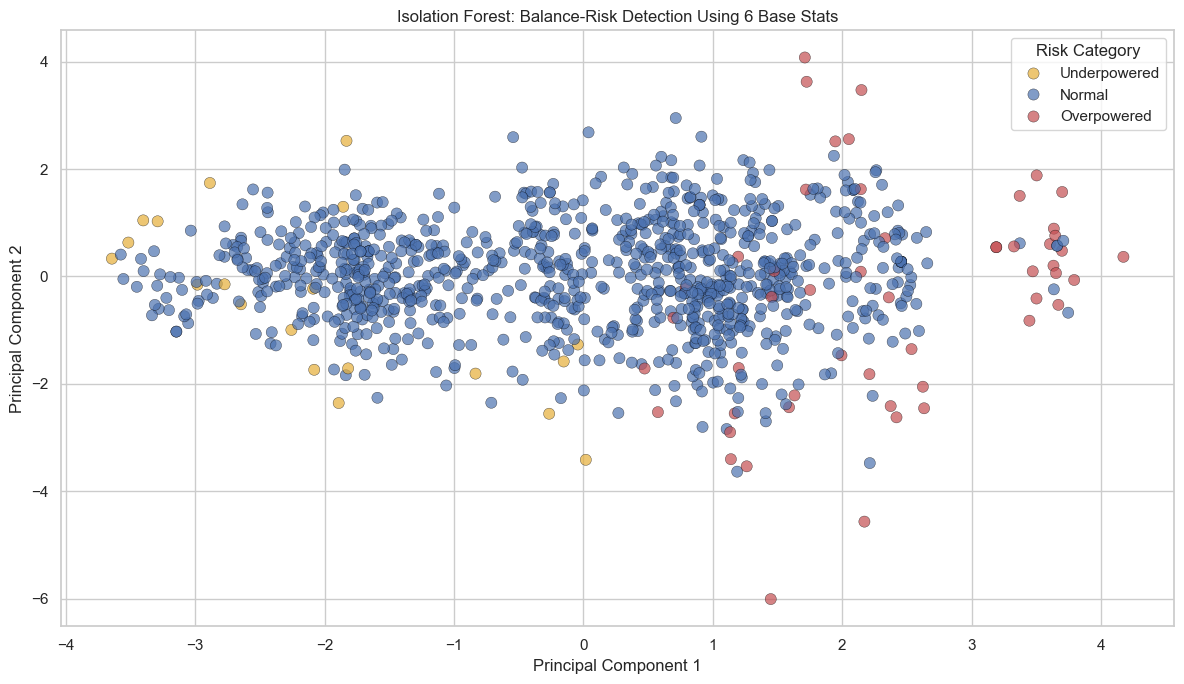

In [39]:
# ---------------------------------------------------------
# 6. Balance Risk PCA visual validation
# ---------------------------------------------------------
# Use this plot only if it is not already shown elsewhere in the final presentation.

X_balance_scaled = StandardScaler().fit_transform(X_balance)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_balance_scaled)

plot_balance = eval_balance.copy()
plot_balance["PCA1"] = X_pca[:, 0]
plot_balance["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=plot_balance,
    x="PCA1",
    y="PCA2",
    hue="balance_category",
    hue_order=["Underpowered", "Normal", "Overpowered"],
    palette={
        "Underpowered": "#E6AE38",
        "Normal": "#4C72B0",
        "Overpowered": "#C44E52",
    },
    alpha=0.7,
    s=65,
    edgecolor="black",
    linewidth=0.3,
)
plt.title("Isolation Forest: Balance-Risk Detection Using 6 Base Stats")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Risk Category")
plt.tight_layout()
plt.show()


In [40]:
# ---------------------------------------------------------
# 7. Balance Risk deep dive: most anomalous cases
# ---------------------------------------------------------
# These tables support interpretation. They are optional for slides.

anomalies = eval_balance[eval_balance["anomaly_label"] == -1].copy()
anomalies = anomalies.sort_values("raw_risk_score")

available_id_cols = [c for c in ["name", "pokedex_id", "base_stat_total", "base_stat_total_6"] if c in anomalies.columns]
core_cols = available_id_cols + BASE_STAT_FEATURES + ["raw_risk_score", "balance_category"]
core_cols = list(dict.fromkeys(core_cols))

print("Top 10 most anomalous detected designs:")
display(anomalies[core_cols].head(10).reset_index(drop=True))

print("Top Overpowered anomalies:")
display(
    anomalies[anomalies["balance_category"] == "Overpowered"][core_cols]
    .head(10)
    .reset_index(drop=True)
)

print("Top Underpowered anomalies:")
display(
    anomalies[anomalies["balance_category"] == "Underpowered"][core_cols]
    .head(10)
    .reset_index(drop=True)
)


Top 10 most anomalous detected designs:


,pokedex_id,base_stat_total,base_stat_total_6,hp,attack,defense,sp_attack,sp_defense,speed,raw_risk_score,balance_category
0,213,505,3.034642,-1.885351,-2.268272,5.380193,-2.026756,6.001358,-2.166529,-0.207347,Overpowered
1,242,540,4.714457,6.943241,-2.268272,-2.135346,0.165937,2.433461,-0.424564,-0.164599,Overpowered
2,113,450,1.537591,6.755399,-2.436238,-2.306154,-1.183413,1.306757,-0.598760,-0.155615,Overpowered
3,386,600,5.729852,-0.758297,2.434763,-0.768885,2.695968,-0.758867,2.885170,-0.108882,Overpowered
4,795,570,4.746042,0.030641,1.998053,-1.212985,2.257429,-1.247106,2.920009,-0.094582,Overpowered
5,798,570,4.664678,-0.420181,3.476149,1.998200,-0.373803,-1.472447,1.456759,-0.086538,Overpowered
6,799,570,5.282598,5.741050,0.788701,-0.666400,0.908079,-0.646197,-0.842635,-0.079427,Overpowered
7,174,210,-7.534958,0.744442,-1.596410,-1.964539,-1.014744,-1.885572,-1.818136,-0.078331,Underpowered
8,440,220,-6.971414,1.120127,-2.436238,-2.306154,-1.858088,-0.195515,-1.295546,-0.075311,Underpowered
9,805,570,4.875084,-0.345044,1.796494,4.731124,-0.576205,1.156530,-1.887814,-0.067765,Overpowered


Top Overpowered anomalies:


,pokedex_id,base_stat_total,base_stat_total_6,hp,attack,defense,sp_attack,sp_defense,speed,raw_risk_score,balance_category
0,213,505,3.034642,-1.885351,-2.268272,5.380193,-2.026756,6.001358,-2.166529,-0.207347,Overpowered
1,242,540,4.714457,6.943241,-2.268272,-2.135346,0.165937,2.433461,-0.424564,-0.164599,Overpowered
2,113,450,1.537591,6.755399,-2.436238,-2.306154,-1.183413,1.306757,-0.598760,-0.155615,Overpowered
3,386,600,5.729852,-0.758297,2.434763,-0.768885,2.695968,-0.758867,2.885170,-0.108882,Overpowered
4,795,570,4.746042,0.030641,1.998053,-1.212985,2.257429,-1.247106,2.920009,-0.094582,Overpowered
5,798,570,4.664678,-0.420181,3.476149,1.998200,-0.373803,-1.472447,1.456759,-0.086538,Overpowered
6,799,570,5.282598,5.741050,0.788701,-0.666400,0.908079,-0.646197,-0.842635,-0.079427,Overpowered
7,805,570,4.875084,-0.345044,1.796494,4.731124,-0.576205,1.156530,-1.887814,-0.067765,Overpowered
8,713,514,2.913109,0.932285,1.326190,3.808762,-0.879809,-0.909095,-1.365225,-0.063935,Overpowered
9,874,470,1.372944,1.120127,1.594935,2.134846,-1.689419,-1.885572,0.098026,-0.058844,Overpowered


Top Underpowered anomalies:


,pokedex_id,base_stat_total,base_stat_total_6,hp,attack,defense,sp_attack,sp_defense,speed,raw_risk_score,balance_category
0,174,210,-7.534958,0.744442,-1.596410,-1.964539,-1.014744,-1.885572,-1.818136,-0.078331,Underpowered
1,440,220,-6.971414,1.120127,-2.436238,-2.306154,-1.858088,-0.195515,-1.295546,-0.075311,Underpowered
2,349,200,-7.930810,-1.885351,-2.100307,-1.793731,-2.026756,-0.571083,0.446419,-0.065102,Underpowered
3,202,405,-0.390254,4.501290,-1.495631,-0.495592,-1.250880,-0.458413,-1.191028,-0.061884,Underpowered
4,129,200,-8.048941,-1.885351,-2.268272,-0.598077,-1.858088,-1.885572,0.446419,-0.059517,Underpowered
5,790,400,-0.807331,-1.021276,-1.630003,1.998200,-1.385815,2.283234,-1.051671,-0.056617,Underpowered
6,771,410,-0.467965,-0.570454,-0.588617,1.964039,-1.352081,2.245677,-2.166529,-0.049104,Underpowered
7,446,390,-1.049917,2.435024,0.251211,-1.110500,-1.014744,0.555621,-2.166529,-0.042780,Underpowered
8,39,270,-5.390392,1.683654,-1.092513,-1.793731,-0.846075,-1.697788,-1.643939,-0.041772,Underpowered
9,960,245,-6.552733,-2.261036,-0.756582,-1.622923,-1.183413,-1.697788,0.969008,-0.040138,Underpowered


## Competitive Longevity Evaluation — Regression Setup

The longevity model is evaluated as a regression model. The final target is a 1–5 longevity score derived from Base Stat Total, matching the final longevity notebook. The raw `generation` column is not used as the regression target because it may contain Roman numerals such as `I`, `II`, and `III`.


In [41]:
# ---------------------------------------------------------
# 8. Prepare final longevity target and features
# ---------------------------------------------------------

def bst_to_longevity_score(bst):
    if bst < 300:
        return 1
    elif bst < 400:
        return 2
    elif bst < 500:
        return 3
    elif bst < 600:
        return 4
    return 5

if "base_stat_total" in df.columns:
    bst_for_target = df["base_stat_total"]
else:
    bst_for_target = df[BASE_STAT_FEATURES].sum(axis=1)

eval_longevity = df.copy()
eval_longevity["longevity_target"] = bst_for_target.apply(bst_to_longevity_score)

X_longevity = eval_longevity[LONGEVITY_FEATURES].copy().apply(pd.to_numeric, errors="coerce").fillna(0)
y_longevity = eval_longevity["longevity_target"].astype(float)

print("Longevity feature shape:", X_longevity.shape)
print("Longevity target distribution:")
display(y_longevity.value_counts().sort_index().rename_axis("Longevity Target").reset_index(name="Count"))


Longevity feature shape: (1025, 24)
Longevity target distribution:


,Longevity Target,Count
0,1.0,146
1,2.0,240
2,3.0,329
3,4.0,250
4,5.0,60


In [42]:
# ---------------------------------------------------------
# 9. Train/test split and load/recreate final Random Forest regressor
# ---------------------------------------------------------
# The split and model parameters match the final longevity notebook.

X_train, X_test, y_train, y_test = train_test_split(
    X_longevity,
    y_longevity,
    test_size=0.2,
    random_state=42,
)

longevity_model_candidates = [
    MODELS_DIR / "longevity_random_forest_final.joblib",
    MODELS_DIR / "longevity_RandomForest.joblib",
    MODELS_DIR / "longevity_regressor.joblib",
]

longevity_model = None
loaded_longevity_path = None

for path in longevity_model_candidates:
    if path.exists():
        candidate = joblib.load(path)
        expected = model_expected_features(candidate)
        if expected is None or set(expected) == set(LONGEVITY_FEATURES):
            longevity_model = candidate
            loaded_longevity_path = path
            break
        else:
            print(f"Skipping {path.name}: saved artifact expects {len(expected)} features, not the final longevity schema.")
            print("Expected by artifact:", expected)

if longevity_model is None:
    print("No valid final longevity artifact found. Recreating the final Random Forest regressor for evaluation...")
    longevity_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
    )
    longevity_model.fit(X_train, y_train)
    loaded_longevity_path = MODELS_DIR / "longevity_random_forest_final.joblib"
    joblib.dump(longevity_model, loaded_longevity_path)
    print("Saved recreated final longevity model to:", loaded_longevity_path)
else:
    print("Loaded longevity model from:", loaded_longevity_path)

print("Longevity model type:", type(longevity_model))
print("Longevity model expected features:", model_expected_features(longevity_model))
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Loaded longevity model from: D:\ml_assignment\Predictive-Meta-Balance-System-for-Pokemon\poke-balance-sentinel\models\longevity_random_forest_final.joblib
Longevity model type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Longevity model expected features: ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'type_bug', 'type_dark', 'type_dragon', 'type_electric', 'type_fairy', 'type_fighting', 'type_fire', 'type_flying', 'type_ghost', 'type_grass', 'type_ground', 'type_ice', 'type_normal', 'type_poison', 'type_psychic', 'type_rock', 'type_steel', 'type_water']
Training set shape: (820, 24)
Test set shape: (205, 24)


In [43]:
# ---------------------------------------------------------
# 10. Evaluate final longevity regressor
# ---------------------------------------------------------
# Correct regression metrics: RMSE, MAE, R².
# No accuracy, F1-score, classification report, or confusion matrix is used here.

y_pred = longevity_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

longevity_results = pd.DataFrame([{
    "Model": "Random Forest Regressor",
    "R² Score": r2,
    "RMSE": rmse,
    "MAE": mae,
}])

print("Final Longevity Regression Metrics:")
display(longevity_results)


Final Longevity Regression Metrics:


,Model,R² Score,RMSE,MAE
0,Random Forest Regressor,0.887445,0.384731,0.306053


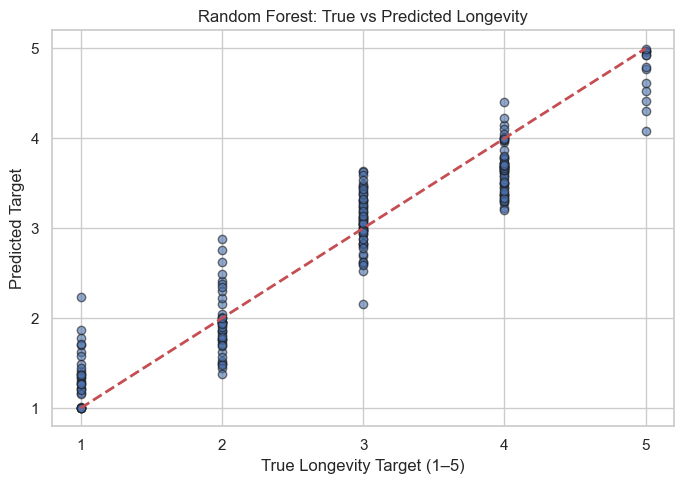

In [44]:
# ---------------------------------------------------------
# 11. True vs Predicted Longevity plot
# ---------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.title("Random Forest: True vs Predicted Longevity")
plt.xlabel("True Longevity Target (1–5)")
plt.ylabel("Predicted Target")
plt.xticks([1, 2, 3, 4, 5])
plt.yticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()


Top 10 Most Important Longevity Features:


,Feature,Importance
0,sp_defense,0.329054
1,hp,0.262821
2,attack,0.151417
3,defense,0.099559
4,sp_attack,0.086087
5,speed,0.058504
6,type_dragon,0.001606
7,type_steel,0.001110
8,type_flying,0.001086
9,type_normal,0.001034


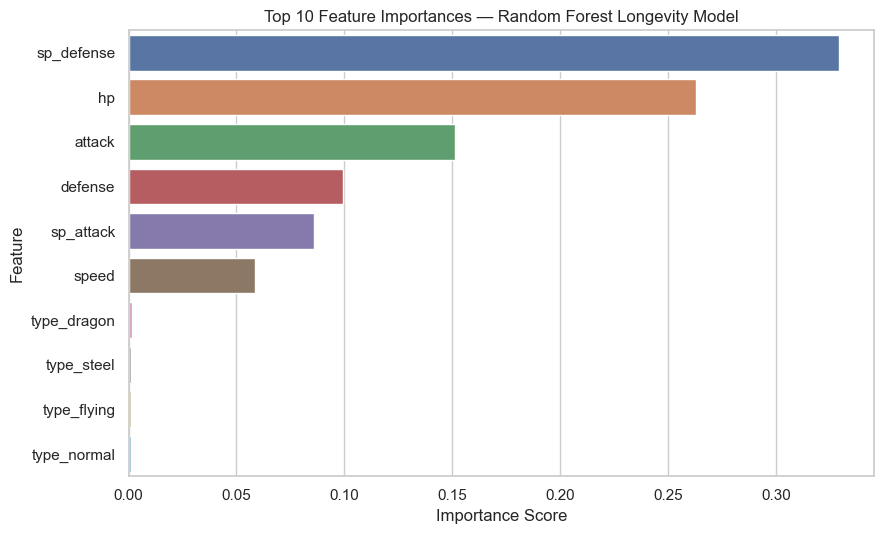

In [45]:
# ---------------------------------------------------------
# 12. Longevity feature importance
# ---------------------------------------------------------

if hasattr(longevity_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "Feature": LONGEVITY_FEATURES,
        "Importance": longevity_model.feature_importances_,
    }).sort_values(by="Importance", ascending=False)

    print("Top 10 Most Important Longevity Features:")
    display(feature_importance.head(10).reset_index(drop=True))

    plt.figure(figsize=(9, 5.5))
    sns.barplot(
        data=feature_importance.head(10),
        x="Importance",
        y="Feature",
        hue="Feature",
        dodge=False,
        legend=False,
    )
    plt.title("Top 10 Feature Importances — Random Forest Longevity Model")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("The loaded longevity model does not expose feature_importances_.")


In [46]:
# ---------------------------------------------------------
# 13. Final evaluation summary for slides/report
# ---------------------------------------------------------

final_summary = f'''
### Final evaluation summary

**Balance Risk**
- Evaluation type: Unsupervised anomaly detection
- Model: Isolation Forest with StandardScaler
- Features: {', '.join(BASE_STAT_FEATURES)}
- Total samples: {len(eval_balance)}
- Normal: {int((eval_balance['balance_category'] == 'Normal').sum())}
- Overpowered: {int((eval_balance['balance_category'] == 'Overpowered').sum())}
- Underpowered: {int((eval_balance['balance_category'] == 'Underpowered').sum())}

**Competitive Longevity**
- Evaluation type: Regression
- Model: Random Forest Regressor
- Features: six base stats + one-hot encoded type columns
- R² Score: {r2:.3f}
- RMSE: {rmse:.3f}
- MAE: {mae:.3f}

**Interpretation**
- Balance Risk is not evaluated using supervised accuracy/F1 because the final task is unsupervised.
- Longevity is not evaluated using a confusion matrix because the final task is regression.
'''

display(Markdown(final_summary))



### Final evaluation summary

**Balance Risk**
- Evaluation type: Unsupervised anomaly detection
- Model: Isolation Forest with StandardScaler
- Features: hp, attack, defense, sp_attack, sp_defense, speed
- Total samples: 1025
- Normal: 953
- Overpowered: 52
- Underpowered: 20

**Competitive Longevity**
- Evaluation type: Regression
- Model: Random Forest Regressor
- Features: six base stats + one-hot encoded type columns
- R² Score: 0.887
- RMSE: 0.385
- MAE: 0.306

**Interpretation**
- Balance Risk is not evaluated using supervised accuracy/F1 because the final task is unsupervised.
- Longevity is not evaluated using a confusion matrix because the final task is regression.


In [47]:
# ---------------------------------------------------------
# 14. Export clean evaluation artifacts for presentation use
# ---------------------------------------------------------
# These CSVs are optional helper files for inserting small tables into slides.

output_dir = PROJECT_ROOT / "evaluation_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

balance_category_counts.to_csv(output_dir / "balance_category_counts.csv", index=False)
balance_eval_summary.to_csv(output_dir / "balance_evaluation_summary.csv", index=False)
longevity_results.to_csv(output_dir / "longevity_regression_metrics.csv", index=False)

if "feature_importance" in globals():
    feature_importance.to_csv(output_dir / "longevity_feature_importance.csv", index=False)

print("Saved clean evaluation outputs to:", output_dir)


Saved clean evaluation outputs to: D:\ml_assignment\Predictive-Meta-Balance-System-for-Pokemon\poke-balance-sentinel\evaluation_outputs


## Final Evaluation Conclusion

The final model evaluation confirms that the two prediction tasks were assessed using methods appropriate to their final modelling objectives.

For the **Balance Risk** task, the final approach was evaluated as an **unsupervised anomaly-detection problem** using an Isolation Forest model with standardized six-stat inputs: HP, Attack, Defense, Sp. Attack, Sp. Defense, and Speed. Since this task does not rely on manually assigned supervised labels, supervised metrics such as accuracy, precision, recall, F1-score, and confusion matrix were not used. The final output identified 953 normal Pokémon, 52 overpowered outliers, and 20 underpowered outliers from 1025 total samples.

For the **Competitive Longevity** task, the final model was evaluated as a **regression problem** using a Random Forest Regressor. The model used the six base stats together with one-hot encoded Pokémon type features. The regression evaluation produced an R² score of 0.887, RMSE of 0.385, and MAE of 0.306, showing that the model captured the overall longevity pattern with low average prediction error.

Overall, the final evaluation supports the selected modelling setup: an unsupervised model for anomaly-based balance screening and a regression model for predicting competitive longevity. The evaluation also confirms that the final notebook outputs are aligned with the corrected feature schemas required by the deployment application.